In [3]:
from datascience import *
%matplotlib inline
path_data = '../../../assets/data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import warnings
warnings.simplefilter(action='ignore')

# Lecture 24 #

## Bootstrap Samples for Creating Confidence Intervals

Load in San Francisco Salary Data for 2019 and create a table that restricts the records to only include positions above the minimum part time salary.


In [4]:
sf = Table.read_table('san_francisco_2019.csv')
min_salary = 15 * 20 * 50
sf_min = sf.where('Salary', are.above(min_salary))

In [5]:
sf_min.num_rows

37103

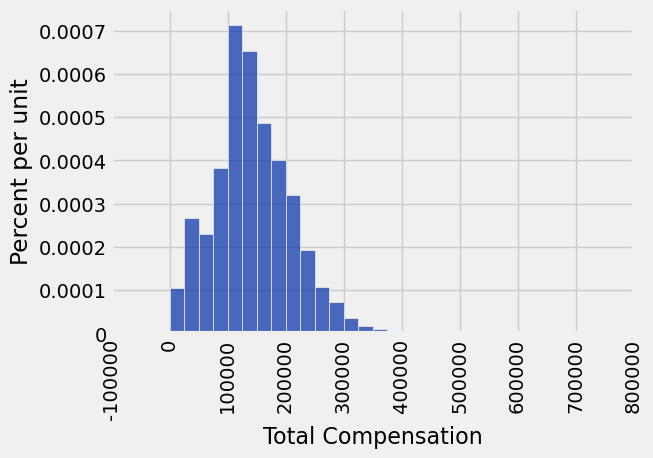

In [6]:
sf_bins = np.arange(0, 726000, 25000)
sf_min.hist('Total Compensation', bins=sf_bins)

In [7]:
# Population Parameter: Median total compensation in the population
def median_comp(t):
    return percentile(50, t.column('Total Compensation'))

median_comp(sf_min)

135747.0

## Bootstrap Estimates of the Parameter (Pretend it is Unknown) 

In [8]:
#Create a function to generate the lower and upper bound
# of 95% of the sampled data based on a slected sample size. 

def confidence_interval_95(sample_size):
    # Collect one random sample from the population
    our_sample = sf_min.sample(sample_size, with_replacement=False)
    median_comp(our_sample)

    # Generate the medians of 1000 bootstrap samples
    num_repetitions = 1000
    bstrap_medians = make_array()
    for i in np.arange(num_repetitions):
        # Resample the same number of rows, with replacement
        bstrap_medians = np.append(bstrap_medians, 
                                   median_comp(our_sample.sample()))

    # Find the middle 95% of medians; that's a confidence interval
    left = percentile(2.5, bstrap_medians)
    right = percentile(97.5, bstrap_medians)
    return make_array(left, right)

confidence_interval_95(100)

array([ 128293.,  150670.])

How wound you edit the function above to create a 90% confidence interval? 

or a 99% confidence interval?

In [9]:
# Create a table that displays the lower and upper bound
# of 95% % of the data for different sample sizes. 

intervals = Table(['k', 'lower', 'upper', 'sample_size'])

for n in [2, 4, 8, 16]:
    for k in np.arange(intervals.num_rows, intervals.num_rows + 20):
        interval = confidence_interval_95(n)
        intervals = intervals.with_row([
            k, interval.item(0), interval.item(1), n
        ])
    
intervals.show(4)

k,lower,upper,sample_size
0,129956,169499,2
1,100128,114756,2
2,157523,232643,2
3,131197,161979,2


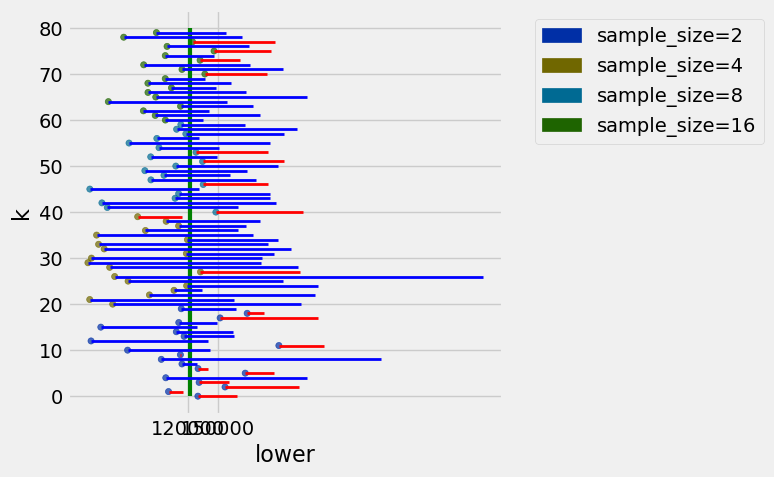

In [10]:
# Generate a graph that shows the confidence intervals compared to the parameter.

intervals.scatter('lower', 'k', group='sample_size')
truth = median_comp(sf)
plots.plot((truth, truth), (0, intervals.num_rows), color='green', lw=3)
plots.xticks([120000, 150000])
for row in intervals.rows:
    if row.item('lower') > truth or row.item('upper') < truth:
        color = 'red'
    else:
        color = 'blue'
    plots.plot((row.item('lower'), row.item('upper')),
               (row.item('k'), row.item('k')),
               color, lw=2)

Review the graph. Does this help you better understand what the confidence level represents?

How would you explain it to someone else?

## Confidence Interval for Unknown Population Mean

Import the Maternal Data Table.

In this case we don't have the advantage of knowing the population parameter, which is a more realistic situation for data analysis. 

We are now curious about the age of the mothers.

In [14]:
# Random sample of mother-newborn pairs
births = Table.read_table('baby.csv')
births.show(3)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


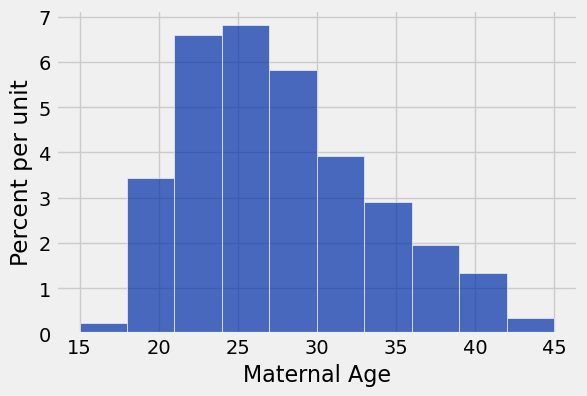

In [12]:
births.hist('Maternal Age')

In [16]:
# Find the average age of mothers in the sample

np.average(births.column('Maternal Age'))

27.228279386712096

### Question
What is the average age of the mothers in the population?

The average we found is a Sample Statistic. We want to use that data to estimate the Population Parameter for the mean age of mothers (in this time period).

In [17]:
#Create a function to show one bootstrap sample's mean.

def one_bootstrap_mean():
    resample = births.sample()
    return np.average(resample.column('Maternal Age'))

In [18]:
# Generate means from 3000 bootstrap samples
num_repetitions = 3000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append(bstrap_means, one_bootstrap_mean())

### Bootstrap Percentile Method for Confidence Interval

The interval of estimates is the "middle 95%" of the bootstrap estimates.

This is called a *95% confidence interval* for the mean age in the population.

In [19]:
# Get the endpoints of the 95% confidence interval
left = percentile(2.5, bstrap_means)
right = percentile(97.5, bstrap_means)

make_array(left, right)

array([ 26.90034072,  27.56388416])

Interpret this confidence interval using the previous sentence structure given.


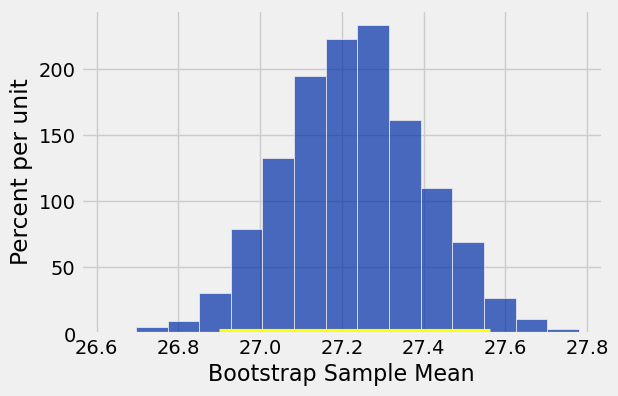

In [20]:
# Create a histogram that displays the bootstrap sample means. 
resampled_means = Table().with_columns(
    'Bootstrap Sample Mean', bstrap_means
)
resampled_means.hist(bins=15)

#Plots the region for the 95% conficence interval. Do not edit. 
plots.plot([left, right], [0, 0], color='yellow', lw=8);

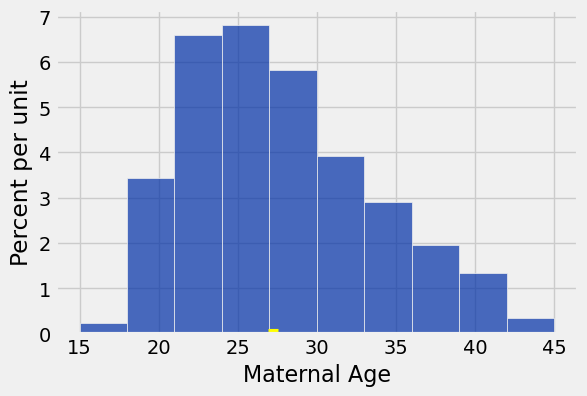

In [21]:
# Create a histogram that shows the maternal age distribution (of the individuals) from the original table.

births.hist('Maternal Age')

#Plots the region for the 95% conficence interval. Do not edit. 
plots.plot([left, right], [0, 0], color='yellow', lw=8);

## Using the Confidence Interval for Testing Hypotheses

Given the following study scenario, determine if the confidence interval supports the Null or Alternative Hypothesis.
    
* **Null:** The average age of mothers in the population is 25 years; the random sample average is different due to chance.
* **Alternative:** The average age of the mothers in the population is not 25 years.

Suppose you use the 5% cutoff for the p-value.

Based on the confidence interval, which hypothesis would you pick?